In [1]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

categories = ['sci.space', 'rec.autos', 'talk.politics.misc']

data = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)


df = pd.DataFrame({'text': data.data, 'category': [data.target_names[i] for i in data.target]})

print(df.head())
print(f"Total documents: {len(df)}")

                                                text            category
0  \n\n\n\n\n\nYour bad English?  (See quote abov...  talk.politics.misc
1  I was a graduate student in the early 1980s, a...  talk.politics.misc
2  \nIt doesn't make a whole lot of difference, a...           sci.space
3                                           \n\n\n\n           rec.autos
4  Yesterday, I went to the Boeing shareholders m...           sci.space
Total documents: 2752


In [2]:
df.to_csv('20newsgroups_subset.csv', index=False)

In [3]:
import pandas as pd

df = pd.read_csv('20newsgroups_subset.csv')
print(df.head())
print(f"Total documents: {len(df)}")

                                                text            category
0  \n\n\n\n\n\nYour bad English?  (See quote abov...  talk.politics.misc
1  I was a graduate student in the early 1980s, a...  talk.politics.misc
2  \nIt doesn't make a whole lot of difference, a...           sci.space
3                                           \n\n\n\n           rec.autos
4  Yesterday, I went to the Boeing shareholders m...           sci.space
Total documents: 2752


In [6]:
df = df.dropna(subset=['text']).reset_index(drop=True)

print(f"Number of documents after dropping NaNs: {len(df)}")

Number of documents after dropping NaNs: 2675


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_tfidf = vectorizer.fit_transform(df['text'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")

TF-IDF matrix shape: (2675, 10000)


In [8]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

components_list = [50, 100, 200]
terms = vectorizer.get_feature_names_out()
n_top_terms = 10

svd_results = []

for n_components in components_list:
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced = svd.fit_transform(X_tfidf)

    explained_variance = svd.explained_variance_ratio_.sum()
    print(f"\nComponents: {n_components}, Explained variance (approx): {explained_variance:.4f}")

    print("Top terms for first 5 topics:")
    for topic_idx, topic in enumerate(svd.components_[:5]):
        top_terms_idx = topic.argsort()[::-1][:n_top_terms]
        top_terms = [terms[i] for i in top_terms_idx]
        print(f"Topic {topic_idx+1}: {', '.join(top_terms)}")

    svd_results.append({
        "Components": n_components,
        "ExplainedVariance": explained_variance
    })


Components: 50, Explained variance (approx): 0.1068
Top terms for first 5 topics:
Topic 1: car, people, like, space, just, don, think, know, good, new
Topic 2: car, cars, engine, dealer, ford, oil, good, price, miles, buy
Topic 3: space, car, shuttle, nasa, launch, orbit, mission, engine, thanks, cars
Topic 4: men, gay, homosexual, sex, sexual, partners, homosexuals, promiscuous, male, study
Topic 5: insurance, health, private, car, space, tax, care, mail, government, canada

Components: 100, Explained variance (approx): 0.1714
Top terms for first 5 topics:
Topic 1: car, people, like, space, just, don, think, know, good, new
Topic 2: car, cars, engine, dealer, ford, oil, good, price, miles, buy
Topic 3: space, car, shuttle, nasa, launch, orbit, mission, engine, thanks, earth
Topic 4: men, gay, homosexual, sex, sexual, partners, homosexuals, promiscuous, male, study
Topic 5: insurance, health, private, car, space, tax, care, mail, government, canada

Components: 200, Explained variance

In [9]:
with open('lsa_topic_terms.txt', 'w') as f:
    for topic_idx, topic in enumerate(svd.components_[:5]):
        top_terms_idx = topic.argsort()[::-1][:n_top_terms]
        top_terms = [terms[i] for i in top_terms_idx]
        f.write(f"Topic {topic_idx+1}: {', '.join(top_terms)}\n")

In [10]:
import pandas as pd

df_results = pd.DataFrame(svd_results)
df_results.to_csv('svd_results.csv', index=False)
df_results

,Components,ExplainedVariance
0,50,0.106837
1,100,0.171415
2,200,0.274879


In [11]:
from google.colab import files

files.download('lsa_topic_terms.txt')
files.download('svd_results.csv')
files.download('20newsgroups_subset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

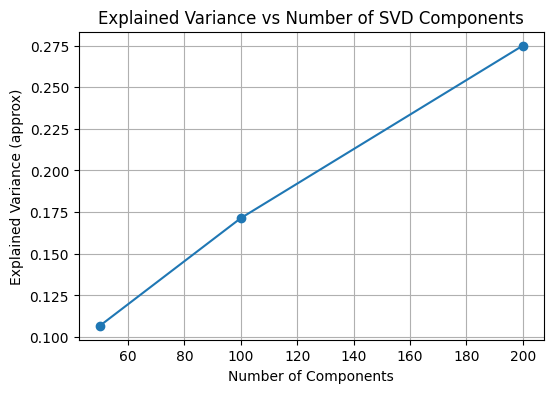

In [12]:
import matplotlib.pyplot as plt

components = df_results['Components']
explained_variance = df_results['ExplainedVariance']

plt.figure(figsize=(6,4))
plt.plot(components, explained_variance, marker='o')
plt.title("Explained Variance vs Number of SVD Components")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance (approx)")
plt.grid(True)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = df['category']

for i, n_components in enumerate(components_list):
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced = svd.fit_transform(X_tfidf)

    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Classification accuracy with {n_components} components: {accuracy:.4f}")

    svd_results[i]["ClassificationAccuracy"] = accuracy


df_results = pd.DataFrame(svd_results)
df_results

Classification accuracy with 50 components: 0.8729
Classification accuracy with 100 components: 0.8766
Classification accuracy with 200 components: 0.8785


,Components,ExplainedVariance,ClassificationAccuracy
0,50,0.106837,0.872897
1,100,0.171415,0.876636
2,200,0.274879,0.878505


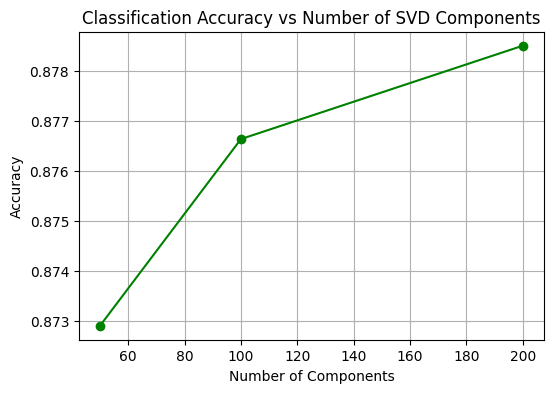

In [15]:
accuracy = df_results['ClassificationAccuracy']

plt.figure(figsize=(6,4))
plt.plot(components, accuracy, marker='o', color='green')
plt.title("Classification Accuracy vs Number of SVD Components")
plt.xlabel("Number of Components")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()